<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/secciones_4_1_4_2_4_3_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---

# Cargar el conjunto de datos
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv', parse_dates=['Date'])
    # parse_dates=['Date'] convierte la columna 'Date' a formato de fecha al cargar
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no se encontró.")
    exit()

# Seleccionar solo las columnas que se muestran en la imagen para una visualización más limpia
columns_to_display = ['Date', 'GOOGL_Close', 'AMZN_Close', 'Treasury_10Y', 'VIX', 'Inflacion_T5YIE']
df_display = df[columns_to_display]

# --- 2. Generar y Estilizar la Tabla 'head()' ---

print("Generando la tabla 'head()'...")

# Obtenemos las primeras 5 filas
head_df = df_display.head()

# Aplicamos el estilo
styled_head = head_df.style.format({
    'Date': '{:%Y-%m-%d}',  # Formato de fecha sin hora
    'GOOGL_Close': '{:.2f}',
    'AMZN_Close': '{:.2f}',
    'Treasury_10Y': '{:.2f}',
    'VIX': '{:.2f}',
    'Inflacion_T5YIE': '{:.2f}'
}).set_table_styles(
    [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
     {'selector': 'tr:nth-of-type(odd)', 'props': 'background-color: #f2f2f2;'}, # Gris claro para filas impares
     {'selector': 'tr:nth-of-type(even)', 'props': 'background-color: #e0eaf1;'}, # Azul claro para filas pares
    ]
).set_caption("Primeras 5 Observaciones del Conjunto de Datos (head)")

# Mostrar la tabla estilizada (esto funciona mejor en Jupyter Notebooks)
display(styled_head)


# --- 3. Generar y Estilizar la Tabla 'tail()' ---

print("\nGenerando la tabla 'tail()'...")

# Obtenemos las últimas 5 filas
tail_df = df_display.tail()

# Aplicamos el mismo estilo
styled_tail = tail_df.style.format({
    'Date': '{:%Y-%m-%d}',
    'GOOGL_Close': '{:.2f}',
    'AMZN_Close': '{:.2f}',
    'Treasury_10Y': '{:.2f}',
    'VIX': '{:.2f}',
    'Inflacion_T5YIE': '{:.2f}'
}).set_table_styles(
    [{'selector': 'th', 'props': [('font-size', '12pt'), ('text-align', 'center'), ('font-weight', 'bold')]},
     {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '8px')]},
     {'selector': 'tr:nth-of-type(odd)', 'props': 'background-color: #f2f2f2;'}, # Gris claro para filas impares
     {'selector': 'tr:nth-of-type(even)', 'props': 'background-color: #e0eaf1;'}, # Azul claro para filas pares
    ]
).set_caption("Últimas 5 Observaciones del Conjunto de Datos (tail)")

# Mostrar la tabla estilizada
display(styled_tail)


# --- Notas para exportar ---
# Si necesitas guardar estas tablas como imágenes para tu tesis, puedes hacerlo así.
# Primero, necesitas instalar una librería adicional: pip install dataframe_image
# import dataframe_image as dfi

# dfi.export(styled_head, 'tabla_head.png')
# dfi.export(styled_tail, 'tabla_tail.png')

# print("\nTablas guardadas como 'tabla_head.png' y 'tabla_tail.png'")

Generando la tabla 'head()'...


,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,Inflacion_T5YIE
0,2021-01-04,85.90,159.33,0.92,26.97,1.98
1,2021-01-05,86.59,160.93,0.95,25.34,2.01
2,2021-01-06,85.73,156.92,1.04,25.07,2.04
3,2021-01-07,88.29,158.11,1.07,22.37,2.09
4,2021-01-08,89.46,159.13,1.11,21.56,2.07



Generando la tabla 'tail()'...


,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,Inflacion_T5YIE
992,2024-12-23,194.41,225.06,4.60,16.78,2.38
993,2024-12-24,195.88,229.05,4.59,14.27,2.39
994,2024-12-26,195.38,227.05,4.58,14.73,2.39
995,2024-12-27,192.54,223.75,4.62,15.95,2.38
996,2024-12-30,191.02,221.30,4.55,17.40,2.35


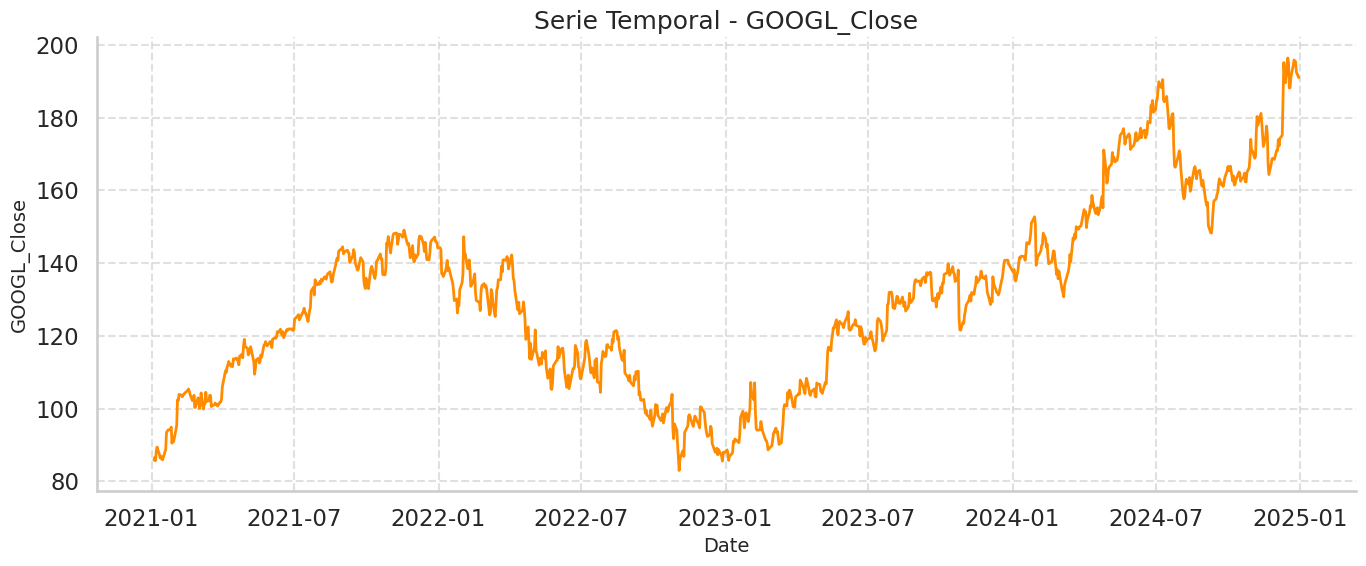

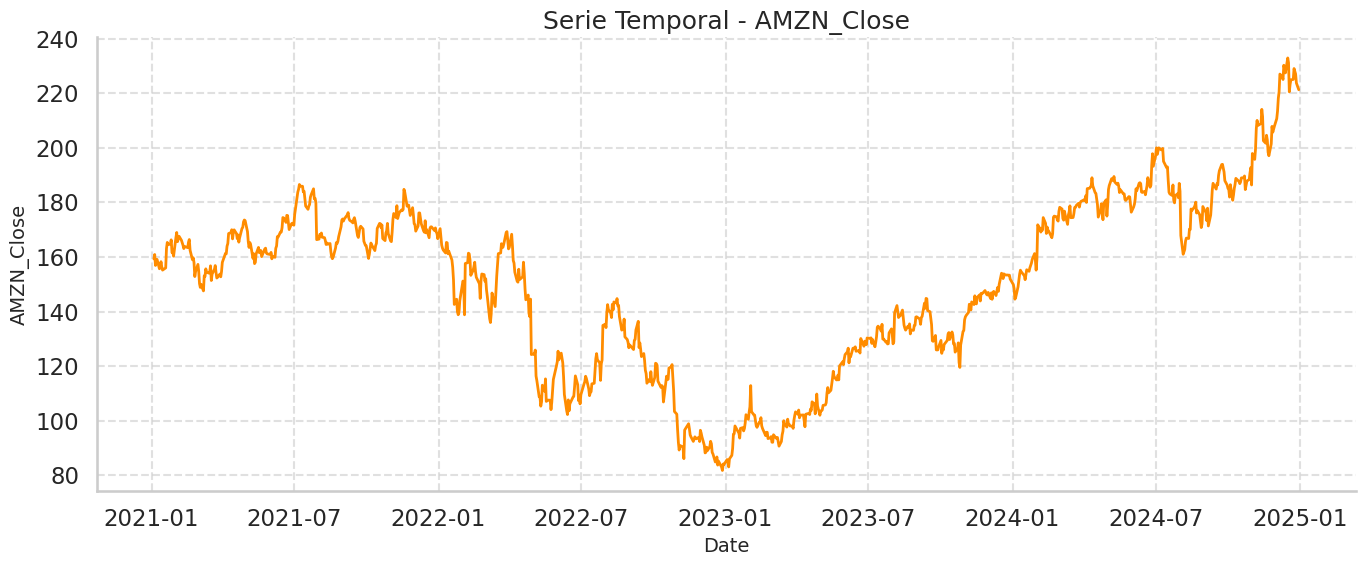

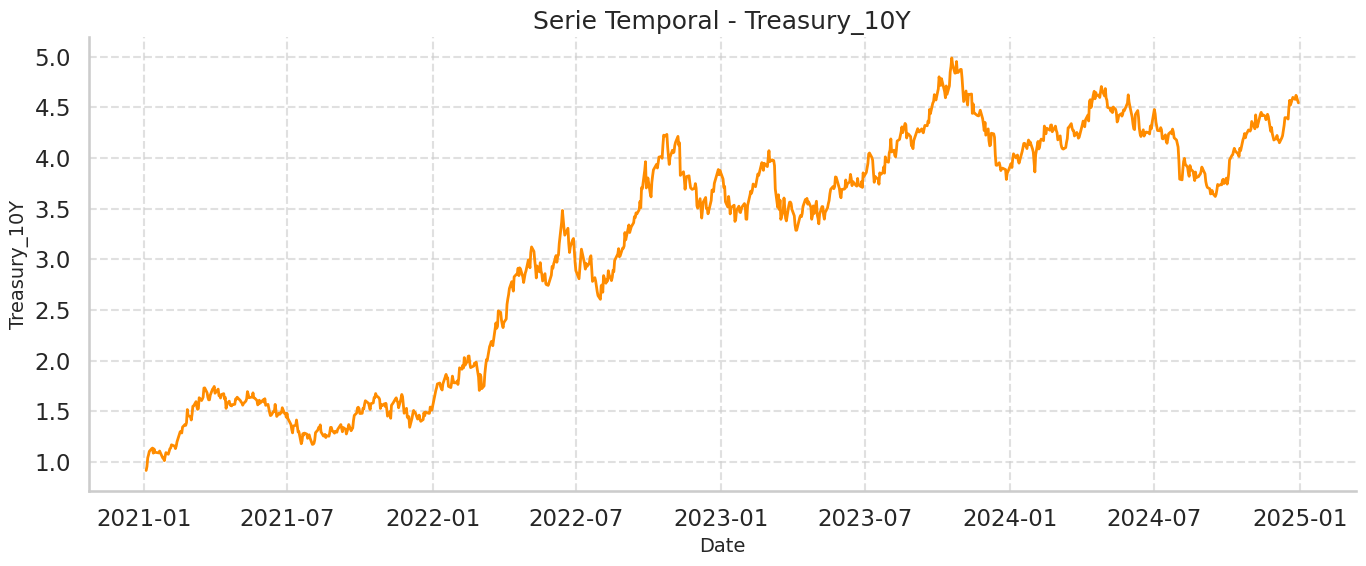

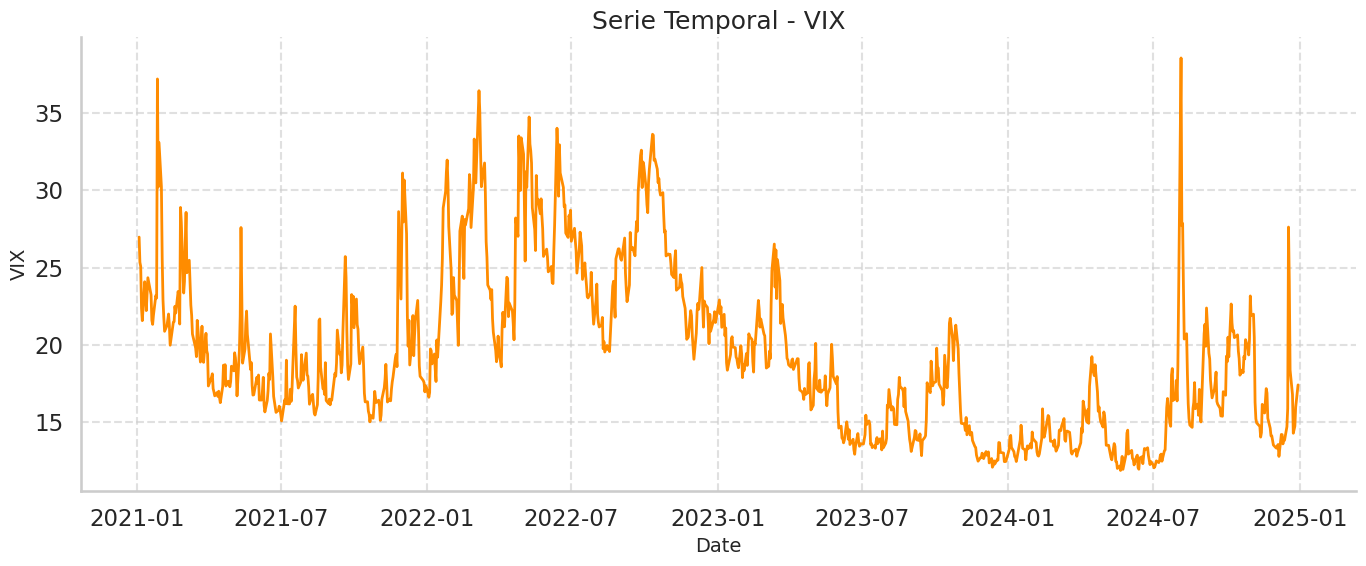

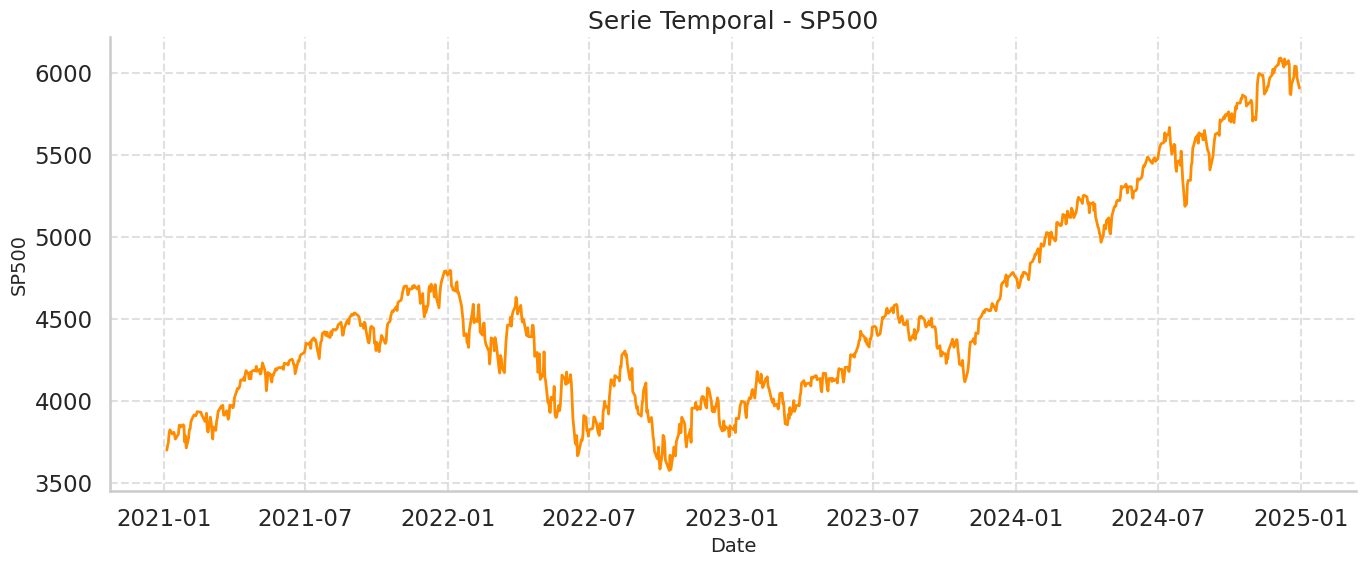

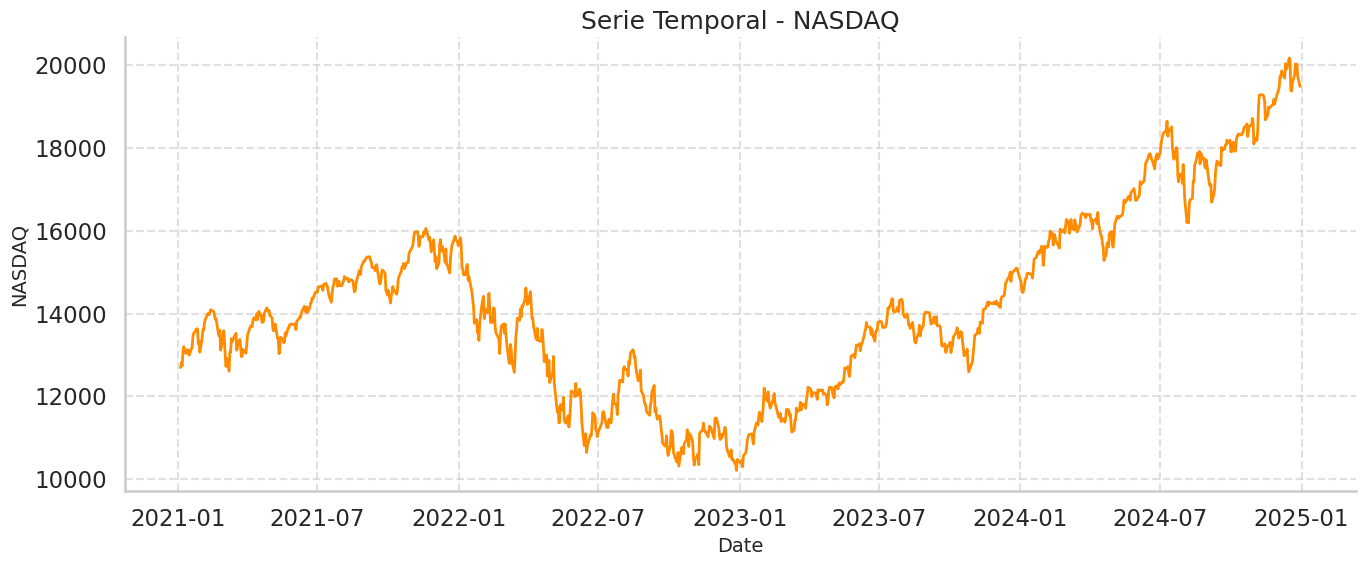

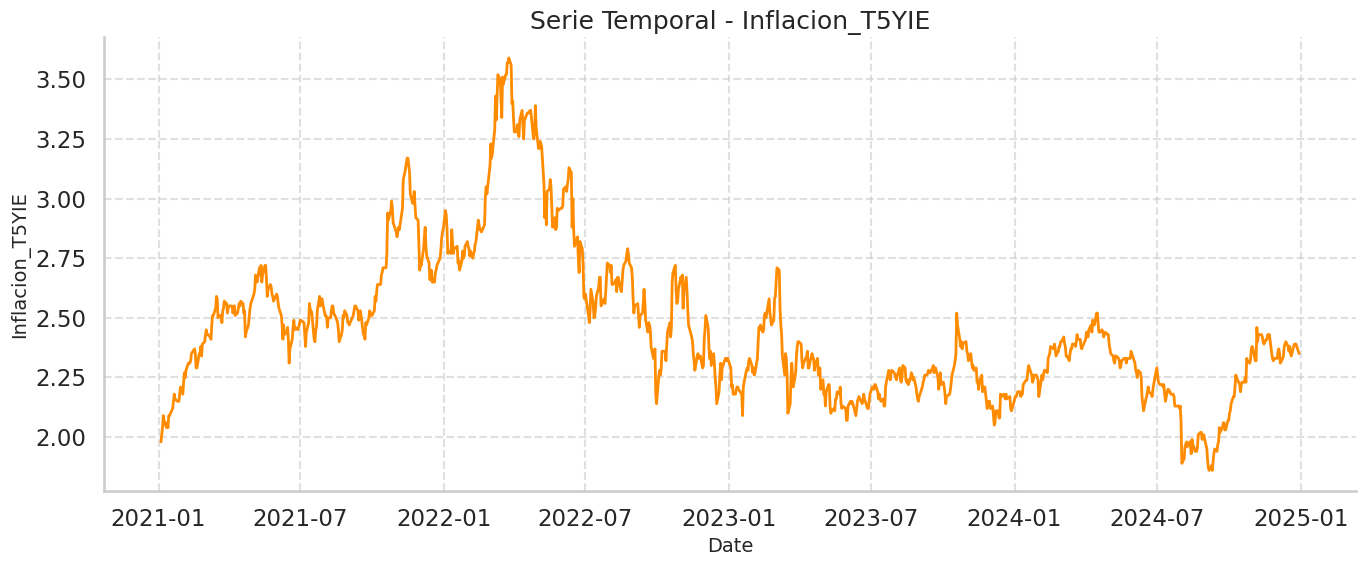


Generando la gráfica combinada...


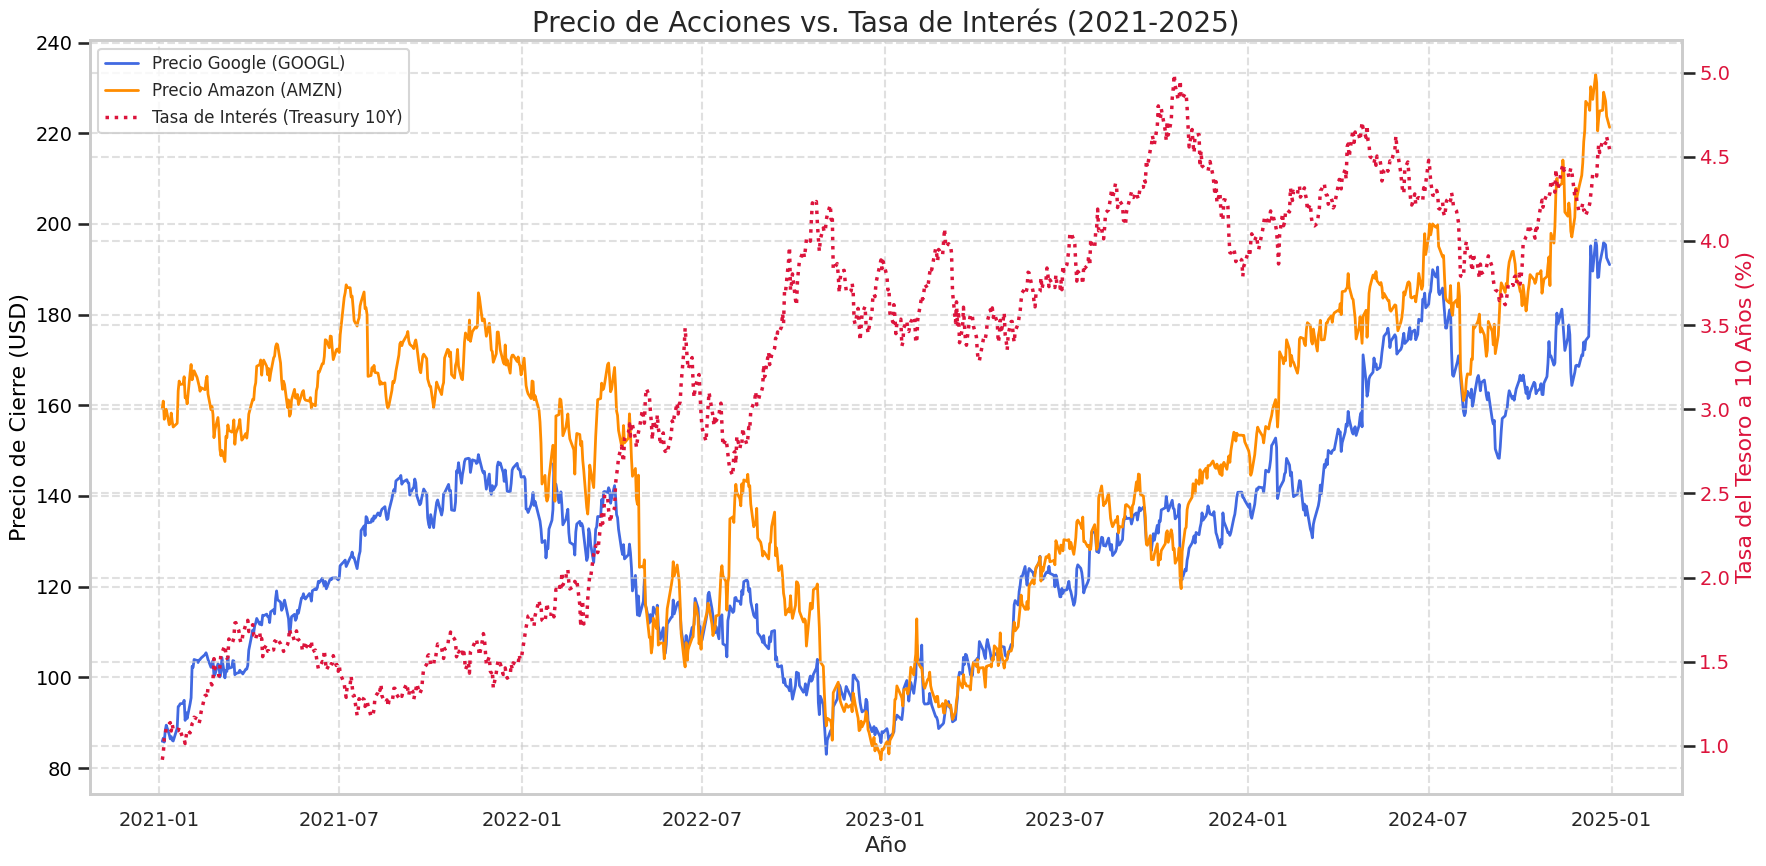

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carga y Preparación de Datos ---

# Configuración de estilo para que los gráficos se parezcan a los de la imagen
sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

# Cargar el conjunto de datos
try:
    df = pd.read_csv('dataset_completo_google_amazon.csv')
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no se encontró.")
    exit()

# Convertir la columna 'Date' a formato datetime y establecerla como índice
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- 2. Generación de las 7 Gráficas de Series Temporales Individuales ---

# Lista de columnas a graficar individualmente
columns_to_plot = [
    'GOOGL_Close', 'AMZN_Close', 'Treasury_10Y', 'VIX',
    'SP500', 'NASDAQ', 'Inflacion_T5YIE'
]

# Bucle para crear cada una de las gráficas
for column in columns_to_plot:
    # Crear la figura y los ejes
    fig, ax = plt.subplots()

    # Graficar la serie temporal
    ax.plot(df.index, df[column], color='darkorange', linewidth=2)

    # Configuración de Títulos y Etiquetas
    ax.set_title(f'Serie Temporal - {column}', fontsize=18)
    ax.set_xlabel('Date', fontsize=14)
    ax.set_ylabel(column, fontsize=14)

    # Quitar los bordes superiores y derechos para un look más limpio
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Ajustar el layout y mostrar la gráfica
    plt.tight_layout()
    plt.show()


# --- 3. Generación de la Gráfica Combinada con Doble Eje Y ---

print("\nGenerando la gráfica combinada...")

# Crear la figura y el primer eje (ax1)
fig, ax1 = plt.subplots(figsize=(18, 9))

# Graficar los precios de las acciones en el primer eje Y (izquierda)
ax1.plot(df.index, df['GOOGL_Close'], color='royalblue', label='Precio Google (GOOGL)', linewidth=2)
ax1.plot(df.index, df['AMZN_Close'], color='darkorange', label='Precio Amazon (AMZN)', linewidth=2)

# Configuración del primer eje Y
ax1.set_xlabel('Año', fontsize=16)
ax1.set_ylabel('Precio de Cierre (USD)', color='black', fontsize=16)
ax1.tick_params(axis='y', labelcolor='black', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)


# Crear el segundo eje Y (ax2) que comparte el mismo eje X
ax2 = ax1.twinx()

# Graficar la tasa de interés en el segundo eje Y (derecha)
ax2.plot(df.index, df['Treasury_10Y'], color='crimson', linestyle=':', label='Tasa de Interés (Treasury 10Y)', linewidth=2.5)

# Configuración del segundo eje Y
ax2.set_ylabel('Tasa del Tesoro a 10 Años (%)', color='crimson', fontsize=16)
ax2.tick_params(axis='y', labelcolor='crimson', labelsize=14)

# Crear leyendas combinadas
# Obtenemos los 'handles' y 'labels' de cada eje y los juntamos
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

# Configuración final
plt.title('Precio de Acciones vs. Tasa de Interés (2021-2025)', fontsize=20)
ax1.grid(True, linestyle='--', alpha=0.6) # Añadir rejilla
fig.tight_layout() # Ajustar el layout para evitar solapamientos
plt.show()